<a href="https://colab.research.google.com/github/analissahaga/fashion-mnist-feature-selection/blob/main/MinistShap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install xgboost shap scikit-learn


In [ ]:
import numpy as np
import shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import (f_classif, mutual_info_classif, RFE)
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score)

RANDOM = 42


Treina o modelo baseline (XGBoost) e obtém os rankings
Aqui você prepara quatro rankings de features (ordem do melhor para o pior), um por seletor:

In [ ]:
import numpy as np
import shap
import xgboost as xgb
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, mutual_info_classif, RFE
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

RANDOM = 42
np.random.seed(RANDOM)

# ===================== 1. CARREGAR =====================
X_full, y_full = fetch_openml('Fashion-MNIST', version=1, return_X_y=True, as_frame=False)
X_full = X_full.astype(np.float32) / 255.0
y_full = np.asarray(y_full).astype(int)
print("Formato original:", X_full.shape, "| classes:", np.unique(y_full))

# ===================== 2. SUBAMOSTRAR =====================
def stratified_subsample(X, y, n):
    idx = []
    per_class = n // len(np.unique(y))
    for c in np.unique(y):
        ci = np.where(y == c)[0]
        ni = min(len(ci), per_class)
        idx.extend(np.random.choice(ci, ni, replace=False))
    idx = np.array(idx)
    return X[idx], y[idx]

X, y = stratified_subsample(X_full, y_full, 20000)
print("Dataset de trabalho:", X.shape)

# ===================== 3. SPLIT =====================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM)

# ===================== 4. BASELINE =====================
def make_xgb():
    return xgb.XGBClassifier(
        n_estimators=200, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='mlogloss', tree_method='hist',
        n_jobs=-1, random_state=RANDOM)

model_full = make_xgb()
model_full.fit(X_train, y_train)
y_proba_full = model_full.predict_proba(X_test)
y_pred_full  = model_full.predict(X_test)

acc_full = accuracy_score(y_test, y_pred_full)
f1_full  = f1_score(y_test, y_pred_full, average='macro')
auc_full = roc_auc_score(y_test, y_proba_full, multi_class='ovr', average='macro')

print(f"BASELINE XGBoost (784 features): acc={acc_full:.4f} | F1={f1_full:.4f} | AUC={auc_full:.4f}")



Formato original: (70000, 784) | classes: [0 1 2 3 4 5 6 7 8 9]
Dataset de trabalho: (20000, 784)
BASELINE XGBoost (784 features): acc=0.8848 | F1=0.8837 | AUC=0.9917


Rankins Shap, ANOVA, Mi, RFE

> Adicionar aspas



In [ ]:
# --- 1) SHAP ---
explainer = shap.TreeExplainer(model_full)
sv = explainer(X_train[:5000])                     # amostra p/ acelerar
shap_imp = np.abs(sv.values).mean(axis=(0, 2))
rank_shap = np.argsort(shap_imp)[::-1]

# --- 2) ANOVA-F (f_classif) ---
f_scores, _ = f_classif(X_train, y_train)
rank_anova = np.argsort(f_scores)[::-1]

# --- 3) Mutual Information ---
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM)
rank_mi = np.argsort(mi_scores)[::-1]

# --- 4) RFE (usa o próprio XGBoost como estimador) ---
rfe_selector = RFE(estimator=make_xgb(), n_features_to_select=10, step=50)
rfe_selector.fit(X_train, y_train)
rank_rfe = np.argsort(rfe_selector.ranking_)   # ranking_ 1 = melhor

rankings = {
    'SHAP':    rank_shap,
    'ANOVA-F': rank_anova,
    'MI':      rank_mi,
    'RFE':     rank_rfe,
}


Avaliação

In [ ]:
def eval_ranking(order, ks):
    accs, f1s, aucs = [], [], []
    for k in ks:
        feats = order[:k]
        m = make_xgb()
        m.fit(X_train[:, feats], y_train)
        p = m.predict_proba(X_test[:, feats])
        pred = np.argmax(p, axis=1)

        accs.append(accuracy_score(y_test, pred))
        f1s.append(f1_score(y_test, pred, average='macro'))
        aucs.append(roc_auc_score(y_test, p, multi_class='ovr', average='macro'))
    return {'acc': accs, 'f1': f1s, 'auc': aucs}

ks = [10, 25, 50, 100, 200, 400, 784]

results = {name: eval_ranking(order, ks) for name, order in rankings.items()}


Graficos

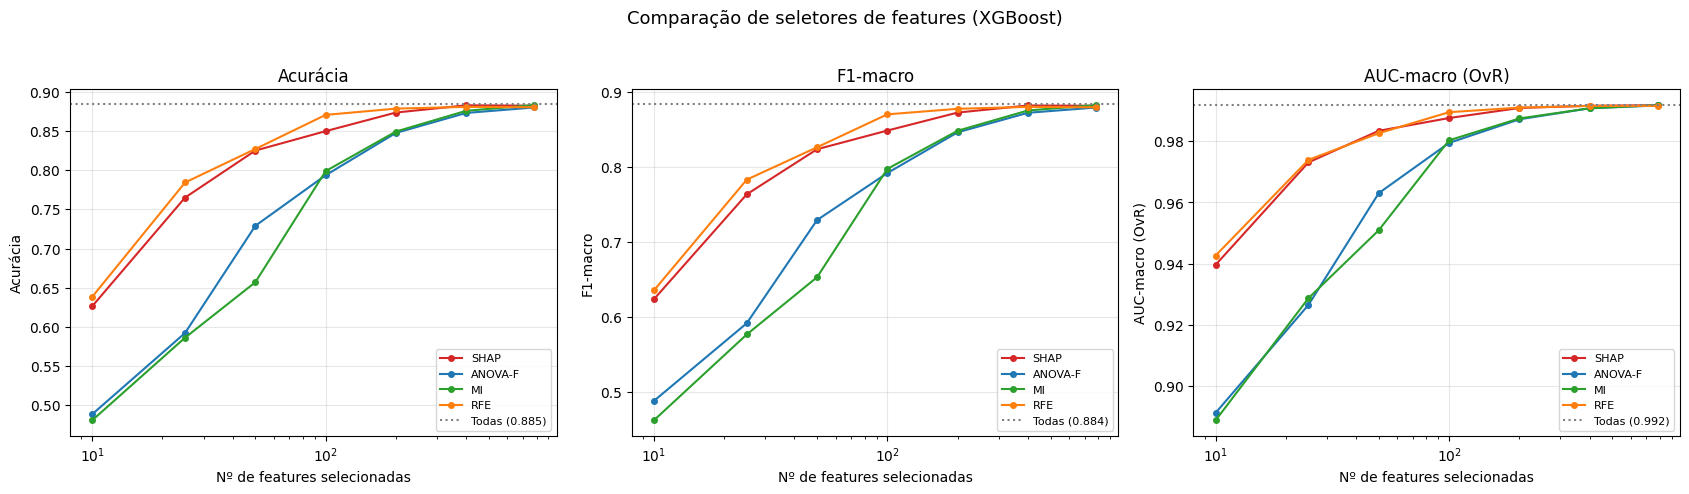

In [ ]:
import matplotlib.pyplot as plt

colors = {'SHAP': '#d62728', 'ANOVA-F': '#1f77b4',
          'MI': '#2ca02c', 'RFE': '#ff7f0e'}
metrics = [('acc', 'Acurácia'), ('f1', 'F1-macro'), ('auc', 'AUC-macro (OvR)')]
baselines = {'acc': acc_full, 'f1': f1_full, 'auc': auc_full}

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
for ax, (mkey, mtitle) in zip(axes, metrics):
    for name, order in rankings.items():
        ax.plot(ks, results[name][mkey], 'o-', color=colors[name], label=name, markersize=4)
    ax.axhline(baselines[mkey], color='gray', ls=':', label=f'Todas ({baselines[mkey]:.3f})')
    ax.set_xscale('log')
    ax.set_xlabel('Nº de features selecionadas')
    ax.set_ylabel(mtitle)
    ax.set_title(mtitle)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Comparação de seletores de features (XGBoost)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


Tabela

In [ ]:
import pandas as pd

k_fixed = 100
idx = ks.index(k_fixed)
print(f"\n=== Resumo com {k_fixed} features selecionadas ===")
rows = []
for name in rankings:
    rows.append({
        'Seletor': name,
        'F1-macro': results[name]['f1'][idx],
        'AUC-macro': results[name]['auc'][idx],
    })
df = pd.DataFrame(rows).sort_values('F1-macro', ascending=False)
df['ΔF1 vs baseline'] = df['F1-macro'] - f1_full
df['ΔAUC vs baseline'] = df['AUC-macro'] - auc_full
print(df.round(4).to_string(index=False))



=== Resumo com 100 features selecionadas ===
Seletor  F1-macro  AUC-macro  ΔF1 vs baseline  ΔAUC vs baseline
    RFE    0.8700     0.9895          -0.0138           -0.0023
   SHAP    0.8483     0.9875          -0.0354           -0.0042
     MI    0.7973     0.9803          -0.0864           -0.0115
ANOVA-F    0.7917     0.9794          -0.0920           -0.0123


/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


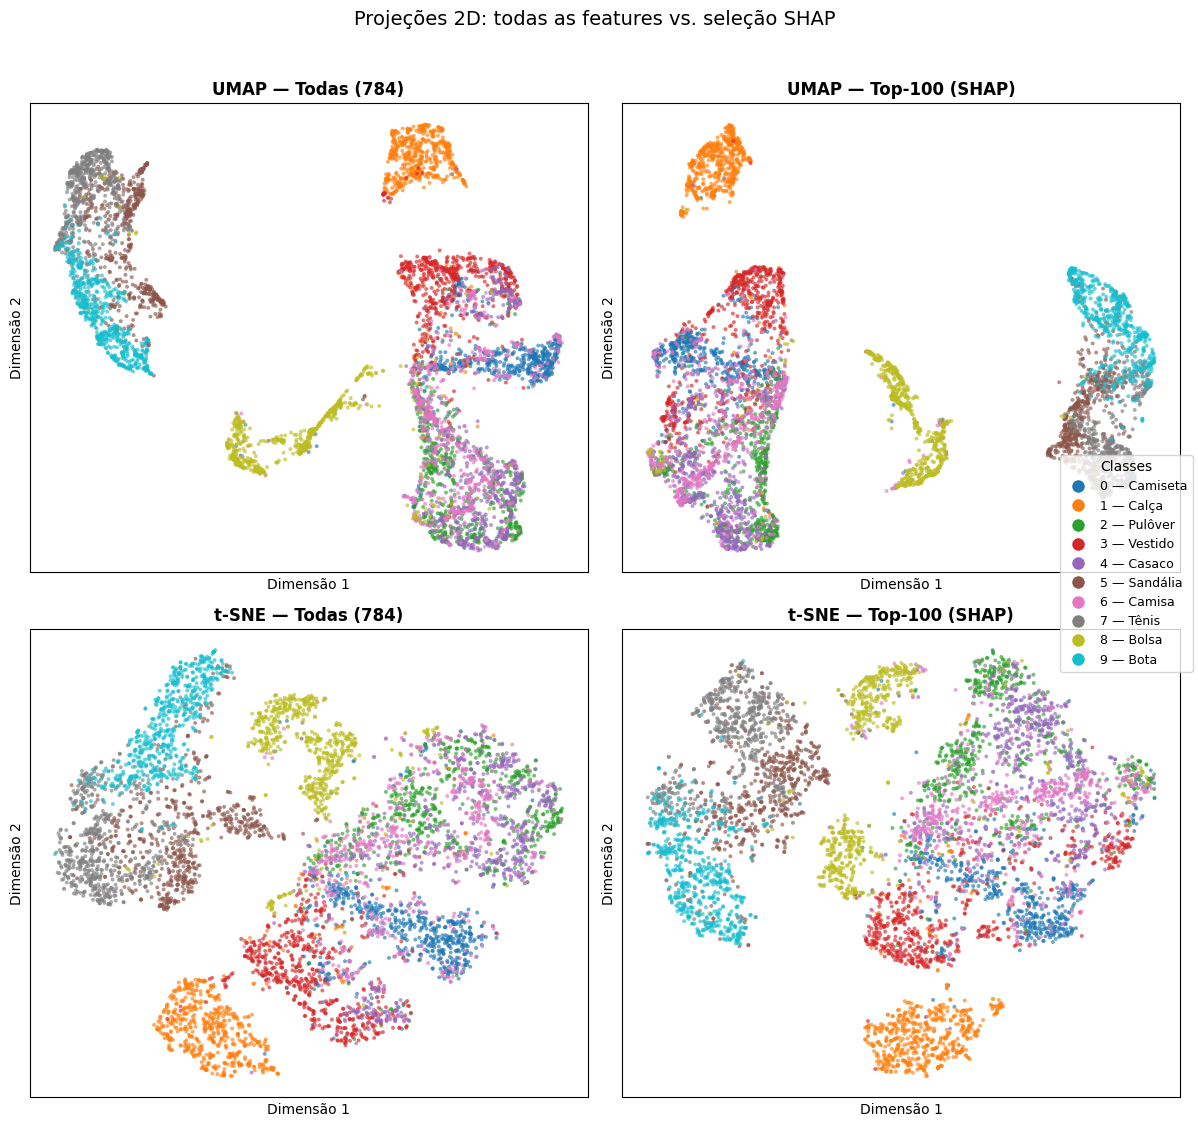

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import umap
from sklearn.manifold import TSNE

# ============ 1. Prepara os dados de projeção (subamostra p/ agilizar) ============
# Use ~6000 pontos para UMAP/t-SNE rodarem rápido
def stratified_subsample(X, y, n):
    idx = []
    per_class = n // len(np.unique(y))
    for c in np.unique(y):
        ci = np.where(y == c)[0]
        ni = min(len(ci), per_class)
        idx.extend(np.random.choice(ci, ni, replace=False))
    return X[np.array(idx)], y[np.array(idx)]

X_proj, y_proj = stratified_subsample(X, y, 6000)

# feats_sel = os 100 pixels escolhidos pelo SHAP (seu ranking[:100])
feats_sel = rank_shap[:100]

# ============ 2. Projeções (todas vs. top-100) ============
RANDOM = 42

# UMAP
umap_full = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM).fit_transform(X_proj)
umap_sel  = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=RANDOM).fit_transform(X_proj[:, feats_sel])

# t-SNE
tsne_full = TSNE(n_components=2, perplexity=30, random_state=RANDOM).fit_transform(X_proj)
tsne_sel  = TSNE(n_components=2, perplexity=30, random_state=RANDOM).fit_transform(X_proj[:, feats_sel])

# ============ 3. Figura 2x2 no estilo do artigo ============
class_names = ['Camiseta', 'Calça', 'Pulôver', 'Vestido', 'Casaco',
               'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
plots = [
    (axes[0, 0], umap_full,  'UMAP — Todas (784)'),
    (axes[0, 1], umap_sel,   'UMAP — Top-100 (SHAP)'),
    (axes[1, 0], tsne_full,  't-SNE — Todas (784)'),
    (axes[1, 1], tsne_sel,   't-SNE — Top-100 (SHAP)'),
]

for ax, emb, title in plots:
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=y_proj, cmap='tab10',
                    s=8, alpha=0.65, edgecolors='none')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dimensão 1')
    ax.set_ylabel('Dimensão 2')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(alpha=0.15)

# Legenda única de classes (fora da figura, à direita)
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=plt.cm.tab10(i/10),
                      markersize=10, label=f'{i} — {class_names[i]}') for i in range(10)]
fig.legend(handles=handles, loc='center right', title='Classes', fontsize=9, title_fontsize=10)

plt.suptitle('Projeções 2D: todas as features vs. seleção SHAP', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('projecoes_2d.png', dpi=300, bbox_inches='tight')
plt.savefig('projecoes_2d.pdf', bbox_inches='tight')
plt.show()



In [ ]:
import numpy as np
import pandas as pd

def mostrar_top_features(nome, indices, valores=None, n=20):
    indices = np.asarray(indices)[:n]

    resultado = pd.DataFrame({
        "feature": indices,
        "linha": indices // 28,
        "coluna": indices % 28,
    })

    if valores is not None:
        resultado["importancia"] = np.asarray(valores)[indices]

    print(f"\nTop {n} — {nome}")
    print(resultado.to_string(index=False))

mostrar_top_features("SHAP", rank_shap, shap_imp)
mostrar_top_features("Mutual Information", rank_mi, mi_scores)
mostrar_top_features("ANOVA-F", rank_anova, f_scores)



Top 20 — SHAP
 feature  linha  coluna  importancia
     206      7      10     0.124249
     289     10       9     0.090848
     150      5      10     0.068440
     742     26      14     0.066483
     233      8       9     0.064439
      14      0      14     0.061926
     770     27      14     0.061914
     232      8       8     0.058865
     546     19      14     0.058014
     234      8      10     0.057053
      91      3       7     0.054612
     518     18      14     0.053859
      43      1      15     0.051373
      13      0      13     0.051196
     344     12       8     0.050098
     345     12       9     0.049895
     260      9       8     0.046460
     231      8       7     0.045689
     574     20      14     0.044710
     527     18      23     0.044681

Top 20 — Mutual Information
 feature  linha  coluna  importancia
     150      5      10     0.570325
      94      3      10     0.566415
     122      4      10     0.564814
     206      7      10     0.5

In [ ]:
# Menor ranking_ vem primeiro; ranking 1 indica feature selecionada
rank_rfe_corrigido = np.argsort(rfe_selector.ranking_, kind="stable")

mostrar_top_features("RFE", rank_rfe_corrigido)



Top 20 — RFE
 feature  linha  coluna
      91      3       7
     117      4       5
     150      5      10
     206      7      10
     247      8      23
     309     11       1
     365     13       1
     367     13       3
     389     13      25
     499     17      23
      37      1       9
      89      3       5
     201      7       5
     219      7      23
     280     10       0
     281     10       1
     315     11       7
     337     12       1
     339     12       3
     342     12       6


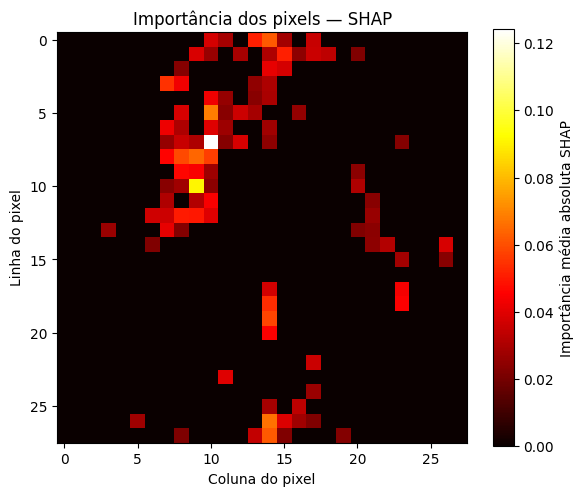

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_shap = rank_shap[:100]

mapa = np.zeros(784)
mapa[top_shap] = shap_imp[top_shap]
mapa = mapa.reshape(28, 28)

plt.figure(figsize=(6, 5))
plt.imshow(mapa, cmap="hot")
plt.colorbar(label="Importância média absoluta SHAP")
plt.title("Importância dos pixels — SHAP")
plt.xlabel("Coluna do pixel")
plt.ylabel("Linha do pixel")
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd

# SHAP: (feature, importância)
shap = [
    (206, 0.124249), (289, 0.090848), (150, 0.068440),
    (742, 0.066483), (233, 0.064439), (14, 0.061926),
    (770, 0.061914), (232, 0.058865), (546, 0.058014),
    (234, 0.057053), (91, 0.054612), (518, 0.053859),
    (43, 0.051373), (13, 0.051196), (344, 0.050098),
    (345, 0.049895), (260, 0.046460), (231, 0.045689),
    (574, 0.044710), (527, 0.044681)
]

# Mutual Information: (feature, importância)
mi = [
    (150, 0.570325), (94, 0.566415), (122, 0.564814),
    (206, 0.556292), (178, 0.550885), (123, 0.546666),
    (151, 0.538708), (234, 0.535897), (179, 0.534126),
    (207, 0.533813), (95, 0.532409), (66, 0.530659),
    (262, 0.528152), (67, 0.523814), (177, 0.523003),
    (39, 0.520122), (124, 0.519767), (149, 0.516634),
    (233, 0.514747), (152, 0.510940)
]

# ANOVA-F: (feature, importância)
anova = [
    (40, 3489.433197), (95, 3331.810726), (417, 3285.071609),
    (445, 3257.501569), (94, 3244.053703), (389, 3227.794445),
    (123, 3207.664573), (122, 3205.424727), (67, 3194.415078),
    (69, 3157.979744), (473, 3124.416464), (96, 3095.886150),
    (68, 3090.344105), (41, 3073.414705), (39, 3049.934739),
    (70, 3036.147623), (361, 3024.545676), (43, 2981.480163),
    (124, 2960.341481), (150, 2957.828083)
]

# Features selecionadas pelo RFE
rfe = [
    91, 117, 150, 206, 247, 309, 365, 367, 389, 499,
    37, 89, 201, 219, 280, 281, 315, 337, 339, 342
]

# Converte cada lista em um dicionário com posição e importância.
def criar_dicionario(valores):
    return {
        feature: {"posição": posicao, "importância": importancia}
        for posicao, (feature, importancia) in enumerate(valores, start=1)
    }

shap_dict = criar_dicionario(shap)
mi_dict = criar_dicionario(mi)
anova_dict = criar_dicionario(anova)

todas_features = sorted(
    set(shap_dict) | set(mi_dict) | set(anova_dict) | set(rfe)
)

linhas = []

for feature in todas_features:
    s = shap_dict.get(feature, {})
    m = mi_dict.get(feature, {})
    a = anova_dict.get(feature, {})

    linhas.append({
        "feature_pixel": feature,
        "SHAP_posição": s.get("posição"),
        "SHAP_importância": s.get("importância"),
        "MI_posição": m.get("posição"),
        "MI_importância": m.get("importância"),
        "ANOVA-F_posição": a.get("posição"),
        "ANOVA-F_importância": a.get("importância"),
        "RFE_selecionada": feature in rfe
    })

tabela = pd.DataFrame(linhas)

# Ordena primeiro pelas features encontradas em mais métodos
colunas_metodos = [
    "SHAP_posição", "MI_posição", "ANOVA-F_posição", "RFE_selecionada"
]
tabela["n_metodos"] = (
    tabela[["SHAP_posição", "MI_posição", "ANOVA-F_posição"]].notna().sum(axis=1)
    + tabela["RFE_selecionada"].astype(int)
)

tabela = tabela.sort_values(
    ["n_metodos", "feature_pixel"],
    ascending=[False, True]
).drop(columns="n_metodos")

display(tabela)

# Salva para abrir no Excel
tabela.to_excel("comparacao_features.xlsx", index=False)


,feature_pixel,SHAP_posição,SHAP_importância,MI_posição,MI_importância,ANOVA-F_posição,ANOVA-F_importância,RFE_selecionada
22,150,3.0,0.068440,1.0,0.570325,20.0,2957.828083,True
29,206,1.0,0.124249,4.0,0.556292,NaN,NaN,True
3,39,NaN,NaN,16.0,0.520122,15.0,3049.934739,False
6,43,13.0,0.051373,NaN,NaN,18.0,2981.480163,False
8,67,NaN,NaN,14.0,0.523814,9.0,3194.415078,False
...,...,...,...,...,...,...,...,...
58,527,20.0,0.044681,NaN,NaN,NaN,NaN,False
59,546,9.0,0.058014,NaN,NaN,NaN,NaN,False
60,574,19.0,0.044710,NaN,NaN,NaN,NaN,False
61,742,4.0,0.066483,NaN,NaN,NaN,NaN,False
